<a href="https://colab.research.google.com/github/PolyakovMA/chocolate-review/blob/main/Chocolate_reviews.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

В датасете содержится информация о более чем 1700 шоколадках. В датасете представлена информация о темном шоколаде.

Задача, решаемая в данном ноутбуке - по характеристикам шоколадки научиться предсказывать ее рейтинг без округлений.

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [ ]:
url = "https://raw.githubusercontent.com/PolyakovMA/chocolate-review/main/data/chocolate_train.csv"
url_test = "https://raw.githubusercontent.com/PolyakovMA/chocolate-review/main/data/chocolate_test_new.csv"

X_test = pd.read_csv(url_test)
X_train = pd.read_csv(url)

X_train.head()

,Company,Specific Bean Origin,REF,Review,Cocoa Percent,Company Location,Rating,Bean Type,Broad Bean Origin
0,Willie's Cacao,Rio Caribe,457,2009,72%,U.K.,3.25,Trinitario,Venezuela
1,Beschle (Felchlin),"Ocumare, Premier Cru, Quizas No. 2",508,2010,72%,Switzerland,3.50,,Venezuela
2,Dark Forest,Tanzania,1554,2015,70%,U.S.A.,3.00,,Tanzania
3,Brasstown aka It's Chocolate,Cooproagro,1125,2013,72%,U.S.A.,3.00,Trinitario,Dominican Republic
4,Pralus,"Java, Indonesie",32,2006,75%,France,3.50,Criollo,Indonesia


In [ ]:
X_train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1255 entries, 0 to 1254
Data columns (total 9 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Company               1255 non-null   object 
 1   Specific Bean Origin  1255 non-null   object 
 2   REF                   1255 non-null   int64  
 3   Review                1255 non-null   int64  
 4   Cocoa Percent         1255 non-null   object 
 5   Company Location      1255 non-null   object 
 6   Rating                1255 non-null   float64
 7   Bean Type             1254 non-null   object 
 8   Broad Bean Origin     1254 non-null   object 
dtypes: float64(1), int64(2), object(6)
memory usage: 88.4+ KB


In [ ]:
X_train.describe(include='all')

,Company,Specific Bean Origin,REF,Review,Cocoa Percent,Company Location,Rating,Bean Type,Broad Bean Origin
count,1255,1255,1255.000000,1255.000000,1255,1255,1255.000000,1254,1254
unique,376,762,NaN,NaN,40,58,NaN,38,84
top,Soma,Madagascar,NaN,NaN,70%,U.S.A.,NaN,,Venezuela
freq,35,39,NaN,NaN,461,521,NaN,628,144
mean,NaN,NaN,1045.152191,2012.382470,NaN,NaN,3.176494,NaN,NaN
std,NaN,NaN,551.284249,2.922499,NaN,NaN,0.478948,NaN,NaN
min,NaN,NaN,5.000000,2006.000000,NaN,NaN,1.000000,NaN,NaN
25%,NaN,NaN,593.000000,2010.000000,NaN,NaN,2.750000,NaN,NaN
50%,NaN,NaN,1077.000000,2013.000000,NaN,NaN,3.250000,NaN,NaN
75%,NaN,NaN,1514.000000,2015.000000,NaN,NaN,3.500000,NaN,NaN


In [ ]:
X_train.isna().sum()

,0
Company,0
Specific Bean Origin,0
REF,0
Review,0
Cocoa Percent,0
Company Location,0
Rating,0
Bean Type,1
Broad Bean Origin,1


In [ ]:
X_train.loc[   (X_train['Bean Type'].isna())   |
                (X_train['Broad Bean Origin'].isna())
                ]

,Company,Specific Bean Origin,REF,Review,Cocoa Percent,Company Location,Rating,Bean Type,Broad Bean Origin
697,Mast Brothers,Madagascar,999,2012,72%,U.S.A.,2.5,Trinitario,NaN
1058,Soma,"Three Amigos(Chuao, Wild Bolivia, D.R.)",676,2011,70%,Canada,4.0,NaN,"Ven, Bolivia, D.R."


In [ ]:
X_train.shape

(1255, 9)

In [ ]:
X_train = X_train.dropna()
X_train.shape

(1253, 9)

In [ ]:
y_train = X_train['Rating']
X_train = X_train.drop('Rating', axis=1)

In [ ]:
df_numerical = X_train.select_dtypes(include=['int64', 'float64'])
df_numerical.head()

,REF,Review
0,457,2009
1,508,2010
2,1554,2015
3,1125,2013
4,32,2006


In [ ]:
df_categorical = X_train.select_dtypes(include=['object'])
df_categorical.head()

,Company,Specific Bean Origin,Cocoa Percent,Company Location,Bean Type,Broad Bean Origin
0,Willie's Cacao,Rio Caribe,72%,U.K.,Trinitario,Venezuela
1,Beschle (Felchlin),"Ocumare, Premier Cru, Quizas No. 2",72%,Switzerland,,Venezuela
2,Dark Forest,Tanzania,70%,U.S.A.,,Tanzania
3,Brasstown aka It's Chocolate,Cooproagro,72%,U.S.A.,Trinitario,Dominican Republic
4,Pralus,"Java, Indonesie",75%,France,Criollo,Indonesia


In [ ]:
df_categorical["Cocoa Percent"].unique()

array(['72%', '70%', '75%', '80%', '77%', '68%', '72.5%', '74%', '58%',
       '65%', '82%', '60%', '66%', '64%', '88%', '76%', '81%', '61%',
       '73%', '91%', '67%', '78%', '100%', '85%', '69%', '83%', '62%',
       '71%', '53%', '55%', '90%', '63%', '46%', '86%', '73.5%', '99%',
       '84%', '56%', '50%', '87%'], dtype=object)

In [ ]:
df_numerical["Cocoa Percent"] = df_categorical["Cocoa Percent"].str.rstrip('%').astype(float)
df_numerical.head()

,REF,Review,Cocoa Percent
0,457,2009,72.0
1,508,2010,72.0
2,1554,2015,70.0
3,1125,2013,72.0
4,32,2006,75.0


In [ ]:
X_test["Cocoa Percent"] = X_test["Cocoa Percent"].str.rstrip('%').astype(float)

In [ ]:
df_categorical = df_categorical.drop(columns=["Cocoa Percent"])
df_categorical.head()

,Company,Specific Bean Origin,Company Location,Bean Type,Broad Bean Origin
0,Willie's Cacao,Rio Caribe,U.K.,Trinitario,Venezuela
1,Beschle (Felchlin),"Ocumare, Premier Cru, Quizas No. 2",Switzerland,,Venezuela
2,Dark Forest,Tanzania,U.S.A.,,Tanzania
3,Brasstown aka It's Chocolate,Cooproagro,U.S.A.,Trinitario,Dominican Republic
4,Pralus,"Java, Indonesie",France,Criollo,Indonesia


In [ ]:
numerical = pd.concat([df_numerical, y_train], axis=1)
numerical.head()

,REF,Review,Cocoa Percent,Rating
0,457,2009,72.0,3.25
1,508,2010,72.0,3.50
2,1554,2015,70.0,3.00
3,1125,2013,72.0,3.00
4,32,2006,75.0,3.50


<Axes: >

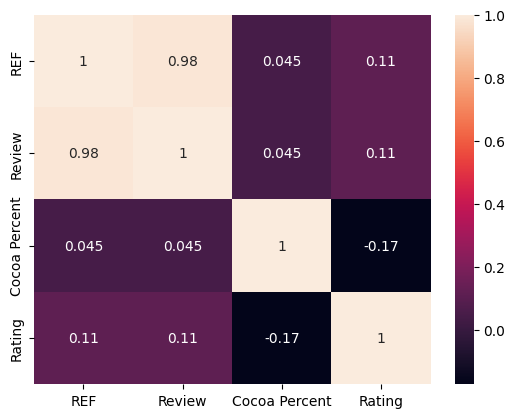

In [ ]:
sns.heatmap(numerical.corr(), annot=True)

Text(0, 0.5, 'Rating')

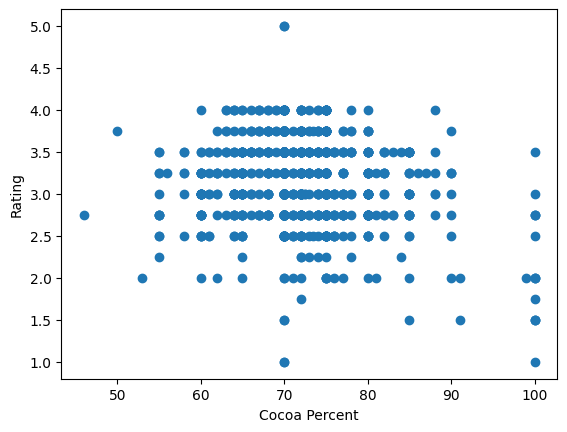

In [ ]:
plt.scatter(numerical['Cocoa Percent'], numerical['Rating'])
plt.xlabel('Cocoa Percent')
plt.ylabel('Rating')

Text(0, 0.5, 'Rating')

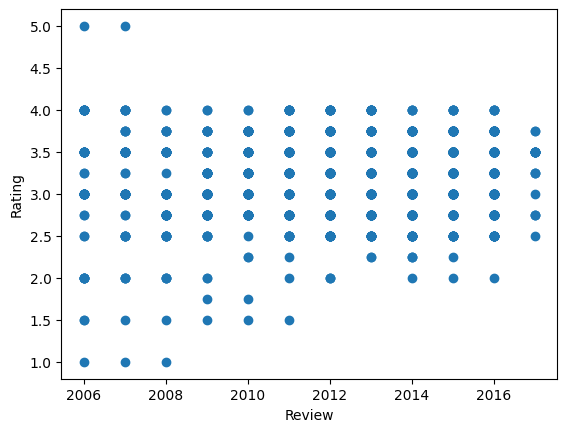

In [ ]:
plt.scatter(numerical['Review'], numerical['Rating'])
plt.xlabel('Review')
plt.ylabel('Rating')

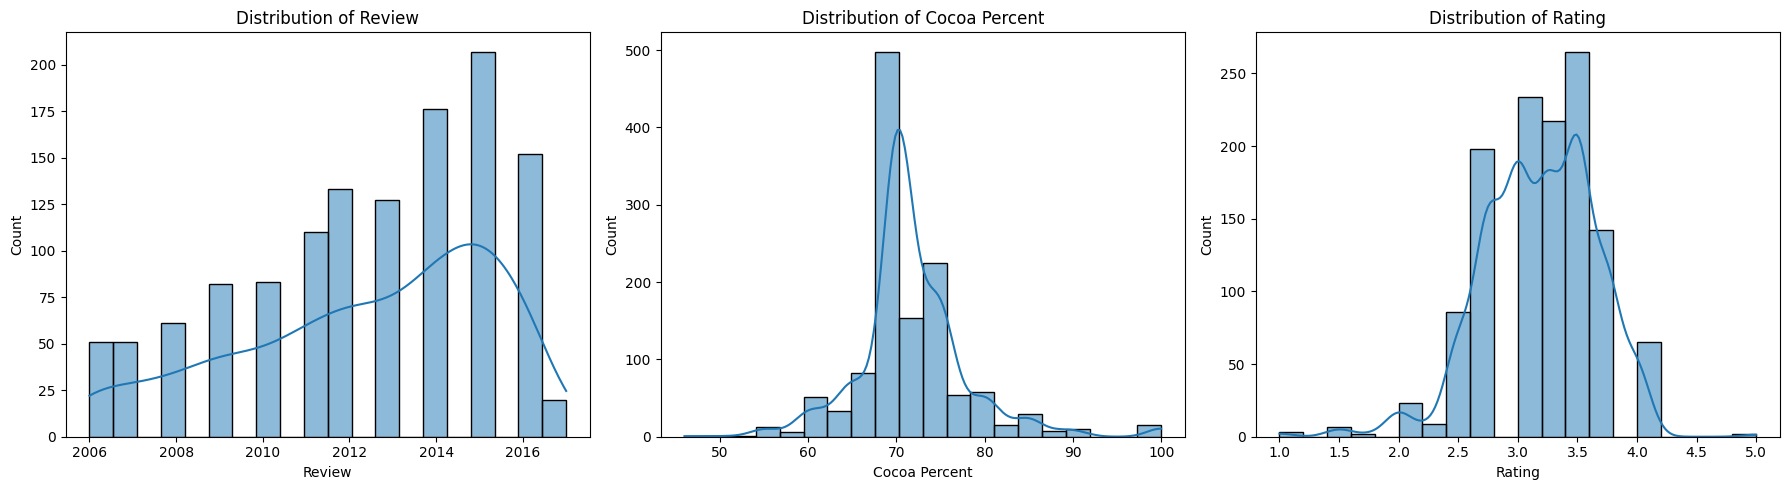

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
features = ['Review', 'Cocoa Percent', 'Rating']

for i, f in enumerate(features):
    sns.histplot(numerical[f], kde=True, ax=axes[i], bins=20)
    axes[i].set_title(f'Distribution of {f}')
    axes[i].set_xlabel(f)
    axes[i].set_ylabel('Count')

plt.tight_layout()
plt.show()

In [ ]:
!pip install dython

In [ ]:
from dython.nominal import associations

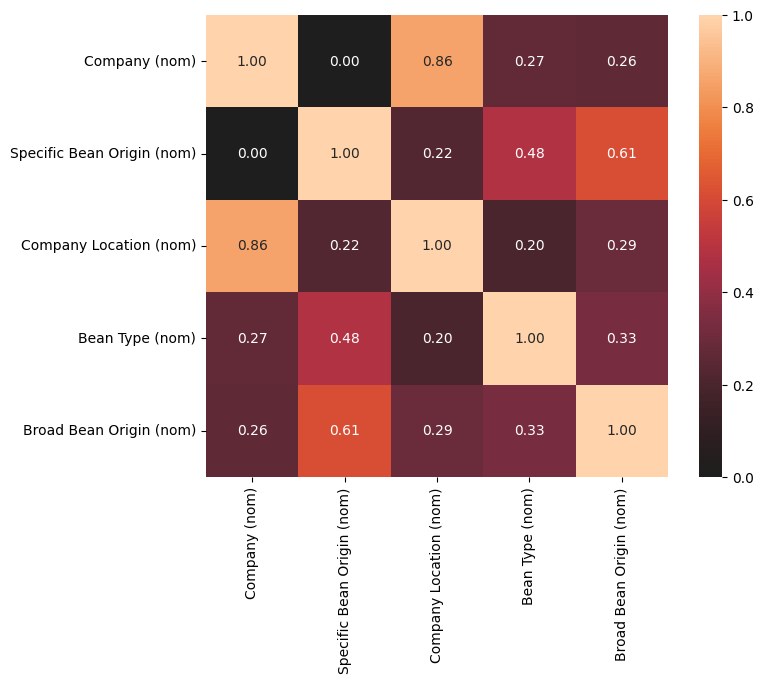

In [ ]:
# на тепловой карте отражена V мера крамера (зависимость между категориальными переменными)
assoc = associations(
    df_categorical,
    nominal_columns='all',
    compute_only=False, # чтобы построить тепловую карту
    figsize=(8, 6),
    mark_columns=True
)

In [ ]:
df_categorical['Bean Type'] = df_categorical['Bean Type'].replace('\xa0', 'Unknown')

In [ ]:
df_categorical['Bean Type'].unique()

array(['Trinitario', 'Unknown', 'Criollo', 'Criollo, Trinitario',
       'Forastero (Arriba)', 'Amazon mix', 'Forastero (Arriba) ASS',
       'Forastero', 'Trinitario, Forastero', 'Forastero (Nacional)',
       'Criollo (Porcelana)', 'Criollo (Amarru)',
       'Forastero(Arriba, CCN)', 'Trinitario (Amelonado)', 'Blend',
       'Forastero (Parazinho)', 'Matina', 'Nacional (Arriba)',
       'Trinitario, TCGA', 'Criollo, Forastero', 'Criollo (Ocumare 77)',
       'Amazon, ICS', 'Nacional', 'Criollo (Ocumare)', 'Criollo, +',
       'Forastero (Catongo)', 'Amazon', 'Criollo (Wild)',
       'Trinitario, Criollo', 'EET', 'Trinitario (85% Criollo)',
       'Criollo (Ocumare 61)', 'Forastero, Trinitario',
       'Blend-Forastero,Criollo', 'Criollo (Ocumare 67)',
       'Forastero (Amelonado)', 'Trinitario, Nacional',
       'Forastero (Arriba) ASSS'], dtype=object)

In [ ]:
X_test['Bean Type'] = X_test['Bean Type'].replace('\xa0', 'Unknown')

In [ ]:
df_categorical['Rating'] = y_train
df_categorical.head()

,Company,Specific Bean Origin,Company Location,Bean Type,Broad Bean Origin,Rating
0,Willie's Cacao,Rio Caribe,U.K.,Trinitario,Venezuela,3.25
1,Beschle (Felchlin),"Ocumare, Premier Cru, Quizas No. 2",Switzerland,Unknown,Venezuela,3.50
2,Dark Forest,Tanzania,U.S.A.,Unknown,Tanzania,3.00
3,Brasstown aka It's Chocolate,Cooproagro,U.S.A.,Trinitario,Dominican Republic,3.00
4,Pralus,"Java, Indonesie",France,Criollo,Indonesia,3.50


In [ ]:
df_categorical.groupby('Bean Type')['Rating'].mean().sort_values()

,Rating
Bean Type,
Forastero (Arriba),2.773438
Forastero (Arriba) ASS,2.875000
Criollo (Ocumare),3.000000
"Forastero, Trinitario",3.000000
"Forastero(Arriba, CCN)",3.000000
Matina,3.000000
"Trinitario, Forastero",3.000000
Trinitario (Amelonado),3.000000
Forastero,3.127358


In [ ]:
for i in df_categorical.columns:
    print(f"{i}: {df_categorical[i].nunique()}")

Company: 376
Specific Bean Origin: 761
Company Location: 58
Bean Type: 38
Broad Bean Origin: 83
Rating: 13


In [ ]:
for i in df_categorical.columns:
    display(df_categorical[i].value_counts())

,count
Company,
Soma,34
Bonnat,20
A. Morin,19
Fresco,17
Valrhona,16
...,...
Dalloway,1
Amazona,1
Love Bar,1


,count
Specific Bean Origin,
Madagascar,38
Peru,34
Ecuador,31
Dominican Republic,29
Chuao,14
...,...
Phantom,1
"Lachua w/ maple sugar, batch 5",1
"Chulucanas, Batch 1",1


,count
Company Location,
U.S.A.,520
France,116
Canada,88
U.K.,74
Ecuador,42
Italy,41
Australia,32
Switzerland,25
Belgium,25


,count
Bean Type,
Unknown,628
Trinitario,284
Criollo,104
Forastero,53
Forastero (Nacional),34
"Criollo, Trinitario",32
Forastero (Arriba),32
Blend,28
Criollo (Porcelana),9


,count
Broad Bean Origin,
Venezuela,144
Ecuador,142
Peru,122
Dominican Republic,104
Madagascar,103
...,...
"Dominican Rep., Bali",1
"Peru, Madagascar",1
"Venezuela, Dom. Rep.",1


,count
Rating,
3.50,265
3.00,234
3.25,217
2.75,198
3.75,142
2.50,86
4.00,65
2.00,23
2.25,9


In [ ]:
df_categorical = df_categorical.drop(columns=['Rating'])
df_categorical.head()

,Company,Specific Bean Origin,Company Location,Bean Type,Broad Bean Origin
0,Willie's Cacao,Rio Caribe,U.K.,Trinitario,Venezuela
1,Beschle (Felchlin),"Ocumare, Premier Cru, Quizas No. 2",Switzerland,Unknown,Venezuela
2,Dark Forest,Tanzania,U.S.A.,Unknown,Tanzania
3,Brasstown aka It's Chocolate,Cooproagro,U.S.A.,Trinitario,Dominican Republic
4,Pralus,"Java, Indonesie",France,Criollo,Indonesia


In [ ]:
df_numerical.head()

,REF,Review,Cocoa Percent
0,457,2009,72.0
1,508,2010,72.0
2,1554,2015,70.0
3,1125,2013,72.0
4,32,2006,75.0


In [ ]:
!pip install catboost -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 99.2/99.2 MB 10.0 MB/s eta 0:00:00


In [ ]:
X_train = pd.concat([df_categorical, df_numerical], axis=1)
X_train.head()


,Company,Specific Bean Origin,Company Location,Bean Type,Broad Bean Origin,REF,Review,Cocoa Percent
0,Willie's Cacao,Rio Caribe,U.K.,Trinitario,Venezuela,457,2009,72.0
1,Beschle (Felchlin),"Ocumare, Premier Cru, Quizas No. 2",Switzerland,Unknown,Venezuela,508,2010,72.0
2,Dark Forest,Tanzania,U.S.A.,Unknown,Tanzania,1554,2015,70.0
3,Brasstown aka It's Chocolate,Cooproagro,U.S.A.,Trinitario,Dominican Republic,1125,2013,72.0
4,Pralus,"Java, Indonesie",France,Criollo,Indonesia,32,2006,75.0


In [ ]:
X_test = X_test[X_train.columns]
X_test.head()

,Company,Specific Bean Origin,Company Location,Bean Type,Broad Bean Origin,REF,Review,Cocoa Percent
0,Ohiyo,"San Juan Estate, Gran Couva",U.S.A.,Trinitario,Trinidad,1594,2015,70.0
1,Blanxart,Organic Dark,Spain,Unknown,,322,2009,72.0
2,Brazen,Maya Mountain,U.S.A.,Trinitario,Belize,1518,2015,80.0
3,Patric,Madagascar,U.S.A.,Trinitario,Madagascar,439,2009,67.0
4,Potomac,"Upala, Batch 12",U.S.A.,Matina,Costa Rica,607,2010,82.0


In [ ]:
from catboost import CatBoostRegressor
from sklearn.metrics import r2_score
from sklearn.model_selection import train_test_split

In [ ]:
X_train_1, X_val_1, y_train_1, y_val_1 = train_test_split(X_train, y_train, test_size=0.2, random_state=42)

In [ ]:
model = CatBoostRegressor(cat_features=list(df_categorical.columns),
                          random_seed=42)

In [ ]:
model.fit(X_train_1, y_train_1)

In [ ]:
pred = model.predict(X_val_1)

In [ ]:
r2_score(y_val_1, pred)

0.1288896946485968

In [ ]:
importances = model.get_feature_importance(prettified=True)
importances

,Feature Id,Importances
0,Company,21.406639
1,Cocoa Percent,14.363680
2,Broad Bean Origin,14.126060
3,Company Location,12.953103
4,Bean Type,12.855912
5,REF,12.675985
6,Specific Bean Origin,6.876444
7,Review,4.742178


In [ ]:
model.fit(X_train, y_train)

In [ ]:
pred = model.predict(X_test)

In [ ]:
result_df = pd.DataFrame({'id': X_test.index, 'Rating': pred})
result_df.head()

,id,Rating
0,0,3.109363
1,1,2.967099
2,2,3.048766
3,3,3.799170
4,4,2.932666


In [ ]:
result_df.to_csv("catboost_submission_0.csv", index=False)

In [ ]:
train_df = X_train.copy()
test_df = X_test.copy()

In [ ]:
#2
X_train_2 = train_df.drop(columns=['REF'])
X_test_2 = test_df.drop(columns=['REF'])

In [ ]:
X_train_2, X_val_2, y_train_2, y_val_2 = train_test_split(X_train_2, y_train, test_size=0.2, random_state=42)

In [ ]:
model_2 = CatBoostRegressor(cat_features=["Company",	"Specific Bean Origin",	"Bean Type",
                                        'Company Location', 'Broad Bean Origin'],
                          random_seed=42)

model_2.fit(X_train_2, y_train_2)

In [ ]:
y_pred_2 = model_2.predict(X_val_2)

In [ ]:
r2_score(y_val_2, y_pred_2)

0.10937984906368192

In [ ]:
!pip install optuna -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 400.9/400.9 kB 21.7 MB/s eta 0:00:00


In [ ]:
import optuna
from sklearn.model_selection import KFold
import numpy as np

In [ ]:
def objective(trial):
    params = {
        'iterations': trial.suggest_int('iterations', 200, 1500),
        'depth': trial.suggest_int('depth', 4, 10),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3),
        'l2_leaf_reg': trial.suggest_float('l2_leaf_reg', 1, 10),
        'bagging_temperature': trial.suggest_float('bagging_temperature', 0, 1),
        'random_strength': trial.suggest_float('random_strength', 0, 2),
        'cat_features': list(df_categorical.columns),
        'loss_function': 'RMSE',
        'random_seed': 42,
        'verbose': 0
    }

    cv = KFold(n_splits=5, shuffle=True, random_state=42)
    scores = []

    for train_idx, val_idx in cv.split(X_train):
        X_tr, X_val = X_train.iloc[train_idx], X_train.iloc[val_idx]
        y_tr, y_val = y_train.iloc[train_idx], y_train.iloc[val_idx]

        model = CatBoostRegressor(**params)
        model.fit(X_tr, y_tr, verbose=0)

        preds = model.predict(X_val)
        scores.append(r2_score(y_val, preds))

    return np.mean(scores)

In [ ]:
study = optuna.create_study(direction='maximize')  # потому что R² — чем выше, тем лучше
study.optimize(objective, n_trials=30)

[I 2025-10-27 06:35:32,338] A new study created in memory with name: no-name-dab8126c-14dc-407b-a2df-544480e4a872
[I 2025-10-27 06:35:36,276] Trial 0 finished with value: 0.15531595741835694 and parameters: {'iterations': 419, 'depth': 4, 'learning_rate': 0.28802971295879587, 'l2_leaf_reg': 6.824708956936503, 'bagging_temperature': 0.3177440830565723, 'random_strength': 1.9589407489843431}. Best is trial 0 with value: 0.15531595741835694.
[I 2025-10-27 06:36:04,513] Trial 1 finished with value: 0.17967292262572318 and parameters: {'iterations': 537, 'depth': 8, 'learning_rate': 0.0628723432749148, 'l2_leaf_reg': 9.395159128478486, 'bagging_temperature': 0.2324449844913905, 'random_strength': 1.8272950017381233}. Best is trial 1 with value: 0.17967292262572318.
[I 2025-10-27 06:36:26,561] Trial 2 finished with value: 0.15867151759139456 and parameters: {'iterations': 1400, 'depth': 5, 'learning_rate': 0.06704412736253153, 'l2_leaf_reg': 1.6930986355087092, 'bagging_temperature': 0.39711

In [ ]:
print("Лучшие параметры:", study.best_params)
print("Лучший AUC:", study.best_value)

Лучшие параметры: {'iterations': 1449, 'depth': 7, 'learning_rate': 0.01167786708312439, 'l2_leaf_reg': 1.0660787628815214, 'bagging_temperature': 0.5503286931739485, 'random_strength': 1.3837433276139002}
Лучший AUC: 0.1977844899276786


In [ ]:
X_train.head()

,Company,Specific Bean Origin,Company Location,Bean Type,Broad Bean Origin,REF,Review,Cocoa Percent
0,Willie's Cacao,Rio Caribe,U.K.,Trinitario,Venezuela,457,2009,72.0
1,Beschle (Felchlin),"Ocumare, Premier Cru, Quizas No. 2",Switzerland,Unknown,Venezuela,508,2010,72.0
2,Dark Forest,Tanzania,U.S.A.,Unknown,Tanzania,1554,2015,70.0
3,Brasstown aka It's Chocolate,Cooproagro,U.S.A.,Trinitario,Dominican Republic,1125,2013,72.0
4,Pralus,"Java, Indonesie",France,Criollo,Indonesia,32,2006,75.0


In [ ]:
final_model = CatBoostRegressor(**study.best_params,
                                cat_features=list(df_categorical.columns),
                                loss_function='RMSE',
                                random_seed=42,
                                verbose=0
                                )

final_model.fit(X_train, y_train)

In [ ]:
pred = final_model.predict(X_test)

In [ ]:
result_df = pd.DataFrame({'id': X_test.index, 'Rating': pred})

In [ ]:
result_df.to_csv("catboost_submission_cv_3.csv", index=False)

In [ ]:
#4
X_train_2 = X_train.copy()
X_test_2 = X_test.copy()


In [ ]:
X_train_2, X_val_2, y_train_2, y_val_2 = train_test_split(X_train_2, y, test_size=0.2, random_state=42)

In [ ]:
model = CatBoostRegressor(cat_features=["Company",	"Specific Bean Origin",	"Bean Type",
                                        'Company Location', 'Broad Bean Origin'],
                          random_seed=42)

model.fit(X_train_2, y_train_2)

In [ ]:
y_pred_2 = model.predict(X_val_2)

In [ ]:
r2_score(y_val_2, y_pred_2)

0.1288896946485968

In [ ]:
y_pred = model.predict(X_test_2)

In [ ]:
result_df = pd.DataFrame({'id': X_test_1.index, 'Rating': y_pred})
result_df.head()

,id,Rating
0,0,3.229542
1,1,2.907075
2,2,3.056562
3,3,3.161550
4,4,2.801885


In [ ]:
result_df.to_csv("catboost_submission_2.csv", index=False)